In [ ]:
# Cell 1 — Install dependencies (no Unsloth)
!pip install trl transformers torch datasets requests openenv-core -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 21.1 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Test connection to your HuggingFace Space
import requests

BASE_URL = "https://sujal12334-silicon-flow-ppa.hf.space"

# Test health
health = requests.get(f"{BASE_URL}/health")
print("Health:", health.json())

# Reset environment
reset = requests.post(f"{BASE_URL}/reset")
print("Reset status:", reset.status_code)
obs = reset.json()
print("Blocks to place:", [b['block_id'] for b in obs['observation']['remaining_blocks']])

Health: {'status': 'healthy'}
Reset status: 200
Blocks to place: ['cpu', 'gpu', 'mem', 'io']


In [ ]:
# Cell 3 — Environment interaction functions
import requests
import json
import re

BASE_URL = "https://sujal12334-silicon-flow-ppa.hf.space"

def reset_env():
    r = requests.post(f"{BASE_URL}/reset")
    return r.json()['observation']

def step_env(block_id, x, y, rotation=0):
    r = requests.post(f"{BASE_URL}/step", json={
        "block_id": block_id,
        "x": x,
        "y": y,
        "rotation": rotation
    })
    return r.json()

def extract_action(text):
    """Extract JSON action from LLM output."""
    try:
        return json.loads(text.strip())
    except:
        match = re.search(r'\{[^{}]+\}', text, re.DOTALL)
        if match:
            try:
                return json.loads(match.group(0))
            except:
                pass
    return None

def run_episode(completion_text):
    """
    Run a full episode using actions extracted from LLM completion.
    Returns total reward.
    """
    obs = reset_env()
    remaining = [b['block_id'] for b in obs['remaining_blocks']]
    total_reward = 0.0
    illegal = 0

    # Try to extract multiple actions from the completion
    actions = re.findall(r'\{[^{}]+\}', completion_text, re.DOTALL)

    placed = set()
    next_x = 0.0

    for action_str in actions:
        try:
            action = json.loads(action_str)
            bid = action.get('block_id', '')
            if bid not in remaining or bid in placed:
                continue
            x = float(action.get('x', next_x))
            y = float(action.get('y', 0.0))
            rot = int(action.get('rotation', 0))

            result = step_env(bid, x, y, rot)
            reward = result.get('reward', 0.0)
            total_reward += reward

            if result.get('observation', {}).get('is_legal', False):
                placed.add(bid)
                # Update next_x for packing
                obs_data = result.get('observation', {})
                for pb in obs_data.get('placed_blocks', []):
                    if pb['block_id'] == bid:
                        next_x = pb['x'] + pb['width']
            else:
                illegal += 1

        except Exception as e:
            continue

    completion_rate = len(placed) / len(remaining) if remaining else 0
    return total_reward, completion_rate, illegal

# Test it
obs = reset_env()
print("Environment functions working!")
print(f"Blocks: {[b['block_id'] for b in obs['remaining_blocks']]}")


Environment functions working!
Blocks: ['cpu', 'gpu', 'mem', 'io']


In [ ]:
# Cell 4 — GRPO Reward Function and Dataset
from datasets import Dataset

SYSTEM_PROMPT = """You are SiliconFlow-PPA, an expert chip physical design engineer.
Place logic blocks on a 2D die (normalised 0-1 × 0-1) to minimise wirelength and prevent thermal hotspots.

RULES:
1. Pack blocks left-to-right along y=0
2. Next block x = previous block x + previous block width
3. Never overlap blocks
4. Fit within die: x + width <= 1.0

For EACH block in remaining_blocks, output a JSON action:
{"block_id": "<id>", "x": <float>, "y": <float>, "rotation": 0}

Output ALL placements as a sequence of JSON objects, one per line.
"""

def make_prompt(scenario="small_4block"):
    """Create a prompt for the given scenario."""
    obs = reset_env()
    blocks_info = json.dumps(obs['remaining_blocks'], indent=2)
    netlist_info = json.dumps(obs['netlist'], indent=2)

    return f"""{SYSTEM_PROMPT}

Current state:
- Die size: 1.0 x 1.0
- Blocks to place: {json.dumps([b['block_id'] for b in obs['remaining_blocks']])}
- Block details: {blocks_info}
- Netlist connections: {netlist_info}

Place all blocks. Output one JSON per line for each block."""

def reward_fn(completions, **kwargs):
    """GRPO reward function — runs each completion in the environment."""
    rewards = []
    for completion in completions:
        text = completion[0]['content'] if isinstance(completion, list) else completion
        try:
            total_reward, completion_rate, illegal = run_episode(text)
            # Add small noise to avoid all-zero gradients
            import random
            noise = random.uniform(-0.01, 0.01)
            normalized = (total_reward / 30.0) * completion_rate + noise
            normalized = max(-1.0, min(1.0, normalized))
            rewards.append(float(normalized))
        except Exception as e:
            rewards.append(float(random.uniform(-0.1, 0.0)))

    print(f"Rewards this batch: {rewards}")
    return rewards

# Create dataset — repeat same prompt many times for GRPO
prompts = [make_prompt() for _ in range(50)]
dataset = Dataset.from_dict({
    "prompt": [[{"role": "user", "content": p}] for p in prompts]
})

print(f"Dataset size: {len(dataset)}")
print(f"Sample prompt preview: {prompts[0][:200]}...")
print("Reward function ready!")


Dataset size: 50
Sample prompt preview: You are SiliconFlow-PPA, an expert chip physical design engineer.
Place logic blocks on a 2D die (normalised 0-1 × 0-1) to minimise wirelength and prevent thermal hotspots.

RULES:
1. Pack blocks left...
Reward function ready!


In [ ]:
# Cell 5 — Load SmolLM2 (stable for GRPO)
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

model_name = "HuggingFaceTB/SmolLM2-360M-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto",
)

print("Model loaded!")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Model loaded!
Parameters: 361,821,120


In [ ]:
# Fix tokenizer padding
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Cell 6 — GRPO Training with TRL
from trl import GRPOConfig, GRPOTrainer

training_args = GRPOConfig(
    learning_rate=5e-6,
    weight_decay=0.1,
    warmup_steps=10,
    lr_scheduler_type="cosine",
    optim="adamw_torch",
    logging_steps=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_generations=2,
    max_completion_length=128,
    num_train_epochs=1,
    max_steps=30,
    save_steps=15,
    output_dir="outputs",
    report_to="none",
    bf16=True,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[reward_fn],
    args=training_args,
    train_dataset=dataset,
)

print("Trainer ready! Starting training...")
trainer.train()
print("Training complete!")

Trainer ready! Starting training...
Rewards this batch: [0.0027885359691576742, -0.009499784895546662, -0.004499413632617615, -0.005535785237023545, 0.004729424283280248, 0.0035339897484582255, 0.007843591354096907, -0.008261223347411677]


Step,Training Loss
1,0.000000
2,-0.038667
3,0.002721
4,-0.005396
5,-0.000000
6,-0.000000
7,-0.000000
8,0.000000
9,-0.000000
10,-0.066471


Rewards this batch: [-0.001561563606294591, -0.009404055611238592, -0.005627240503927933, 0.00010710576206724755, -0.009469280606322728, -0.00602324698626703, 0.0029976887555904635, 0.0008988296120643335]
Rewards this batch: [-0.0055911875591860664, 0.0017853136775181737, 0.006188609133556533, -0.00987002480643878, 0.0061163850366561575, 0.003962787899764538, -0.0031949896696401624, -0.006890410003764369]
Rewards this batch: [0.009144261444135623, -0.0032681090977474646, -0.008145083132397042, -0.00806567246333072, 0.006949887326949197, 0.002074520627337822, 0.006142565465487604, 0.004594635733876357]
Rewards this batch: [0.0007245618290940142, 0.009462315279587413, -0.0024293124558329307, 0.0010408126254645399, 0.006588093285059897, 0.0023703950472849216, 0.007234138006215545, 0.0015470429051352413]
Rewards this batch: [0.004091436724298469, -0.009083512326886756, -0.005442034486969063, -0.004212240727957857, -0.00840416046152745, -0.0053441822727793966, -0.007979971411805419, -0.0044

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Rewards this batch: [0.005250216001503025, 0.0007875806023925139, 0.005572529572611165, 0.000607073443903549, -0.00998856207744113, -0.0035168788599065385, -0.009610465152283355, 0.008581972325292344]
Rewards this batch: [0.007574437556463686, 0.006633310587223587, -0.0038497174919467714, -0.00884149667011625, 0.0075601919840808125, 0.00893898890595988, -0.008286930958642424, -0.00028019073366772514]
Rewards this batch: [-0.008615749630632328, 0.005212043305144631, 0.005316688586139755, -0.007432170710004744, -0.0004943524380253746, 0.000996071869898878, -0.004698867421198818, 0.007448660821705149]
Rewards this batch: [-0.0015372411959822616, -0.005764035891158359, 0.000785921775589166, 0.004598621381799523, -0.005976978732206082, -0.0037656741739821014, 0.009902987133217892, 0.0029975611527890706]
Rewards this batch: [-0.0012379983217099197, 0.0003515168207118124, -0.007579916082634686, -0.005506053259368853, -0.003238288757050893, 0.0017661743691446668, -0.00539770534806846, -0.00559

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete!


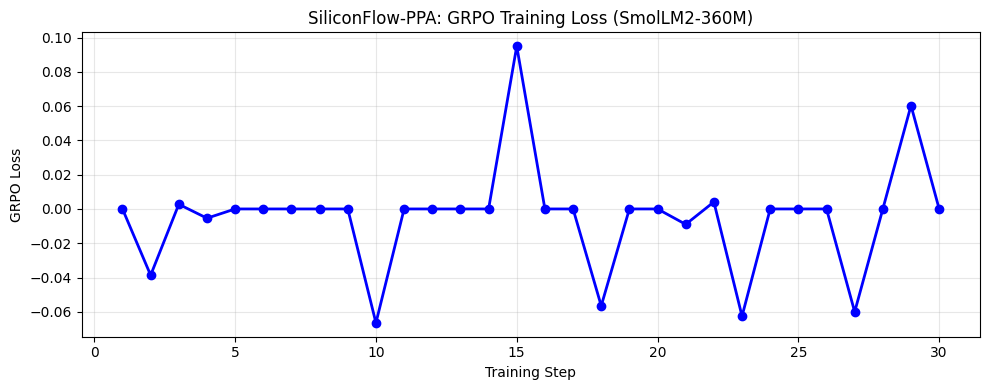

Training steps: 30
Final loss: 0.000000
Plot saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!


In [ ]:
# Cell 7 — Plot training results and save model
import matplotlib.pyplot as plt

# Extract loss values from trainer
loss_history = [x['loss'] for x in trainer.state.log_history if 'loss' in x]
steps = list(range(1, len(loss_history) + 1))

plt.figure(figsize=(10, 4))
plt.plot(steps, loss_history, marker='o', linewidth=2, color='blue')
plt.xlabel("Training Step")
plt.ylabel("GRPO Loss")
plt.title("SiliconFlow-PPA: GRPO Training Loss (SmolLM2-360M)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("grpo_training_loss.png", dpi=150)
plt.show()
print(f"Training steps: {len(loss_history)}")
print(f"Final loss: {loss_history[-1]:.6f}")
print("Plot saved!")

# Save model
model.save_pretrained("siliconflow-ppa-model")
tokenizer.save_pretrained("siliconflow-ppa-model")
print("Model saved!")

In [ ]:
# Cell 8 — Push model to HuggingFace Hub
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
from huggingface_hub import login
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')
login(token=os.environ["HF_TOKEN"])

model.push_to_hub("Sujal12334/SiliconFlow-PPA-SmolLM2")
tokenizer.push_to_hub("Sujal12334/SiliconFlow-PPA-SmolLM2")
print("Model pushed to HuggingFace!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0re24ul/model.safetensors:   0%|          |  601kB /  724MB            

README.md: 0.00B [00:00, ?B/s]

Model pushed to HuggingFace!
